In [1]:
import torch

## Lesson

### Load Data

In [2]:
T = 1000
num_train = 600
tau = 4

In [3]:
time_vector = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time_vector) + torch.rand(T) * 0.2

In [4]:
from matplotlib import pyplot as plt

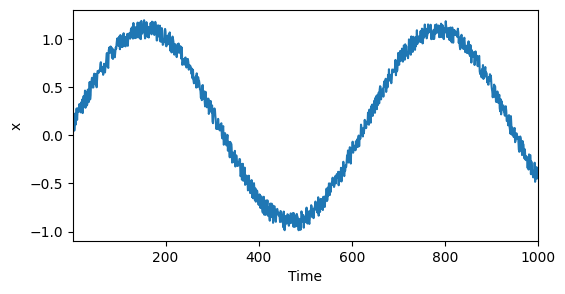

In [5]:
plt.figure(figsize=(6, 3))  # Create a figure with a specific size
plt.plot(time_vector, x)
plt.xlabel("Time")
plt.ylabel("x")
plt.xlim(1, T)
plt.show()



### Make data loader

In [6]:
time_input = torch.stack([x[i: T - tau + i] for i in range(tau)], 1)
time_output = x[tau:].reshape((-1, 1))
train_data = torch.utils.data.TensorDataset(time_input[0:num_train], time_output[0: num_train])
train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True)
val_data = torch.utils.data.TensorDataset(time_input[num_train:], time_output[num_train:])
val_data_loader = torch.utils.data.DataLoader(val_data, batch_size=16, shuffle=True)

### Load Model and train


In [7]:
linear_regression = torch.nn.RNN(tau, 1)
optimizer = torch.optim.SGD(linear_regression.parameters(), lr=0.001)

In [8]:
loss = torch.nn.MSELoss()

In [9]:
max_epoch = 10

In [13]:
for epoch in range(max_epoch):
    linear_regression.train()
    for X, y in train_data_loader:
        y_hat = linear_regression(X)
        l = loss(y_hat[0], y)
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
    with torch.no_grad():
        linear_regression.eval()
        val_loss = sum(loss(linear_regression(X)[0], y) for X, y in val_data_loader)
    print(f'Epoch {epoch + 1}, Loss: {l.item():f}, Val Loss: {val_loss.item() / len(val_data_loader):f}')

Epoch 1, Loss: 0.082283, Val Loss: 0.074741
Epoch 2, Loss: 0.068494, Val Loss: 0.072733
Epoch 3, Loss: 0.012704, Val Loss: 0.070871
Epoch 4, Loss: 0.036631, Val Loss: 0.069080
Epoch 5, Loss: 0.017200, Val Loss: 0.067316
Epoch 6, Loss: 0.032996, Val Loss: 0.065387
Epoch 7, Loss: 0.022498, Val Loss: 0.063929
Epoch 8, Loss: 0.061914, Val Loss: 0.062308
Epoch 9, Loss: 0.052335, Val Loss: 0.060513
Epoch 10, Loss: 0.039247, Val Loss: 0.059191


In [14]:
preds = linear_regression(time_input)[0].reshape(-1).detach().numpy()

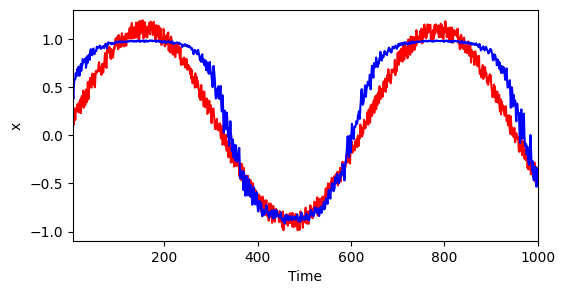

In [15]:
plt.figure(figsize=(6, 3))  # Create a figure with a specific size
plt.plot(time_vector[tau:], x[tau:], 'r')
plt.plot(time_vector[tau:], preds, 'b-')
plt.xlabel("Time")
plt.ylabel("x")
plt.xlim(tau + 1, T)
plt.show()

In [ ]:
multistep_preds = torch.zeros(T)
multistep_preds[:] = x
for i in range(num_train + tau, T):
  multistep_preds[i] = linear_regression(multistep_preds[i - tau: i].reshape((1, -1)))
multistep_preds = multistep_preds.detach().numpy()

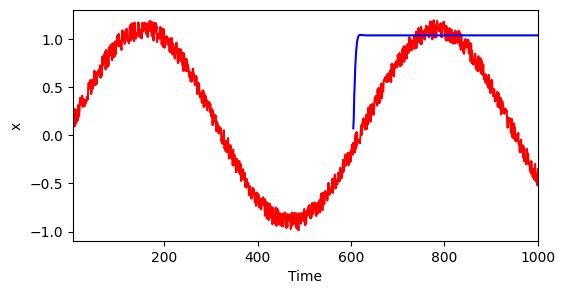

In [ ]:
plt.figure(figsize=(6, 3))  # Create a figure with a specific size
plt.plot(time_vector[tau:], x[tau:], 'r')
plt.plot(time_vector[tau + num_train:], multistep_preds[tau + num_train:], 'b-')
plt.xlabel("Time")
plt.ylabel("x")
plt.xlim(tau + 1, T)
plt.show()

In [ ]:
def k_step_pred(k):
    features = []
    for i in range(tau):
        features.append(x[i : i+T-tau-k+1])
    # The (i+tau)-th element stores the (i+1)-step-ahead predictions
    for i in range(k):
        preds = linear_regression(torch.stack(features[i : i+tau], 1))
        features.append(preds.reshape(-1))
    return features[tau:]

steps = (1, 4, 16, 64)
preds = k_step_pred(steps[-1])

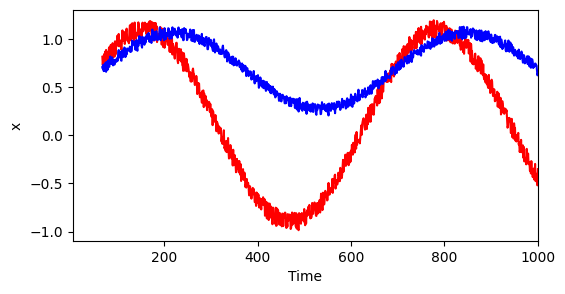

In [ ]:
plt.figure(figsize=(6, 3))  # Create a figure with a specific size
plt.plot(time_vector[tau + 63:], x[tau + 63:], 'r')
plt.plot(time_vector[tau + 63:], preds[3].detach().numpy(), 'b-')
plt.xlabel("Time")
plt.ylabel("x")
plt.xlim(tau + 1, T)
plt.show()

## Exercises

In [ ]:
def train_sin(tau):
  time_input = torch.stack([x[i: T - tau + i] for i in range(tau)], 1)
  time_output = x[tau:].reshape((-1, 1))
  train_data = torch.utils.data.TensorDataset(time_input[0:num_train], time_output[0: num_train])
  train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True)
  val_data = torch.utils.data.TensorDataset(time_input[num_train:], time_output[num_train:])
  val_data_loader = torch.utils.data.DataLoader(val_data, batch_size=16, shuffle=True)
  linear_regression = torch.nn.Linear(tau, 1)
  loss = torch.nn.MSELoss()
  optimizer = torch.optim.SGD(linear_regression.parameters(), lr=0.01)
  max_epochs = 5
  print(f"tau: {tau}")
  for epoch in range(max_epochs):
    for X, y in train_data_loader:
      y_hat = linear_regression(X)
      l = loss(y_hat, y)
      optimizer.zero_grad()
      l.backward()
      optimizer.step()
    with torch.no_grad():
      val_loss = sum(loss(linear_regression(X), y) for X, y in val_data_loader)
  preds = linear_regression(time_input).reshape((-1))
  print(f"Error: {loss(preds, x[tau:])}")

### 1

#### 1

In [ ]:
for tau in range(5, 10):
  train_sin(tau)

tau: 5
Error: 0.00028904739883728325
tau: 6
Error: 0.0011051453184336424
tau: 7
Error: 0.0003053306427318603
tau: 8
Error: 0.00014873885083943605
tau: 9
Error: 0.0013123538810759783


#### 2

In [ ]:
x = torch.sin(0.01 * time_vector)

In [ ]:
tau = 3

In [ ]:
train_sin(tau)

tau: 9
Error: 0.0007127076387405396


#### 3

In [ ]:
x = torch.sin(0.01 * time_vector) + torch.randn(T)

In [ ]:
tau = 3

In [ ]:
moving_average = torch.zeros(T)
for i in range(1, T):
  moving_average[i] = x[0 : i - 1].mean()
time_input = torch.stack([x[i: T - tau + i] for i in range(tau)] + [moving_average[tau:]], 1)
time_output = x[tau:].reshape((-1, 1))
train_data = torch.utils.data.TensorDataset(time_input[0:num_train], time_output[0: num_train])
train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True)
val_data = torch.utils.data.TensorDataset(time_input[num_train:], time_output[num_train:])
val_data_loader = torch.utils.data.DataLoader(val_data, batch_size=16, shuffle=True)
linear_regression = torch.nn.Linear(tau + 1, 1)
loss = torch.nn.MSELoss()
optimizer = torch.optim.SGD(linear_regression.parameters(), lr=0.01)
max_epochs = 5
print(f"tau: {tau}")
for epoch in range(max_epochs):
  for X, y in train_data_loader:
    y_hat = linear_regression(X)
    l = loss(y_hat, y)
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
  with torch.no_grad():
    val_loss = sum(loss(linear_regression(X), y) for X, y in val_data_loader)
preds = linear_regression(time_input).reshape((-1))
print(f"Error: {loss(preds, x[tau:])}")

tau: 3
Error: 1.1145920753479004


### 4

In [ ]:
time_input = torch.stack([x[i: T - tau + i] for i in range(tau)], 1)
time_output = x[tau:].reshape((-1, 1))
train_data = torch.utils.data.TensorDataset(time_input[0:num_train], time_output[0: num_train])
train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True)
val_data = torch.utils.data.TensorDataset(time_input[num_train:], time_output[num_train:])
val_data_loader = torch.utils.data.DataLoader(val_data, batch_size=16, shuffle=True)
linear_regression = torch.nn.Sequential(torch.nn.Linear(tau, 10), torch.nn.ReLU(), torch.nn.Linear(10, 1))
loss = torch.nn.MSELoss()
optimizer = torch.optim.SGD(linear_regression.parameters(), lr=0.01)
max_epochs = 10
print(f"tau: {tau}")
for epoch in range(max_epochs):
  for X, y in train_data_loader:
    y_hat = linear_regression(X)
    l = loss(y_hat, y)
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
  with torch.no_grad():
    val_loss = sum(loss(linear_regression(X), y) for X, y in val_data_loader)
preds = linear_regression(time_input).reshape((-1))
print(f"Error: {loss(preds, x[tau:])}")

tau: 3
Error: 1.1102697849273682
